<a href="https://colab.research.google.com/github/tomasrodriguezr11/Programacion-MIAAD/blob/main/266228_02_semana11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Práctica 02- Semana 11: Regresión lineal con datos categóricos: Costos, Localidades y Salarios**

**Programación para analítica descriptiva y predictiva MIAAD**

*Realizada por: Tomás Eduardo Rodríguez Ramírez*

*Número de matrícula: 266228*

📌 **Objetivos de la Práctica:**

Al finalizar esta práctica, los estudiantes serán capaces de:

- Codificar variables categóricas usando one-hot encoding con K-1 para problemas de regresión
- Realizar AED
- Construir un modelo de regresión con variables dummy
- Interpretar los resultados de los coeficientes
- Analizar los resultados de los errores residuales
- Calcular el desempeño del modelo de regresión.

Problema: Se podría argumentar que el salario está relacionado con el costo de la educación. Por lo tanto, para analizar este argumentos veremos qué sucede cuando usamos las variables independientes cost y location.

# 1. Carga de datos

Carga el conjunto de datos college.csv, que está en campus virtual, en un dataframe. Elige de este conjunto las columnas salary (variable dependiente), cost(variable independiente - numérica) y location (variable independiente categórica).

Realiza lo siguiente:

*   Convierte si es necesario la variable location a tipo de dato categórico
*   Usa la instrucción describe() en las variables salary y cost
* Cuenta la cantidad de datos que hay por categoría en location
* Convierte la variable location usando one-hot encoding



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

# Carga de datos
df = pd.read_csv('/content/drive/MyDrive/ProgramacionMIAAD/college.csv')
df

,id,name,salary,cost,public,location
0,1,Massachusetts Institute of Technology (MIT),119000,189300,Private,NE
1,2,Harvard University,121000,189600,Private,NE
2,3,Dartmouth College,123000,188400,Private,NE
3,4,Princeton University,123000,188700,Private,NE
4,5,Yale University,110000,194200,Private,NE
...,...,...,...,...,...,...
80,81,Colorado State University (CSU),79300,74070,Public,W
81,82,University of Wyoming (UW),80100,69800,Public,W
82,83,Pacific Lutheran University,74900,169200,Private,W
83,84,University of Colorado - Denver,84500,56970,Public,W


In [3]:
# Selección de columnas salary, cost y location
df = df[['salary', 'cost', 'location']]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   salary    85 non-null     int64 
 1   cost      85 non-null     int64 
 2   location  85 non-null     object
dtypes: int64(2), object(1)
memory usage: 2.1+ KB


In [4]:
# Convertir location a variable categórica
df['location'] = df['location'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   salary    85 non-null     int64   
 1   cost      85 non-null     int64   
 2   location  85 non-null     category
dtypes: category(1), int64(2)
memory usage: 1.7 KB


/tmp/ipykernel_15939/4168728146.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['location'] = df['location'].astype('category')


In [5]:
# Estadísticas descriptivas de salary y cost
print(df[['salary','cost']].describe())

              salary           cost
count      85.000000      85.000000
mean    95898.823529  142434.470588
std     11937.121912   53913.064578
min     74900.000000   18260.000000
25%     87100.000000   84670.000000
50%     93200.000000  169200.000000
75%    105000.000000  188700.000000
max    123000.000000  227300.000000


In [6]:
# Conteo de datos por categoría de location
print(df['location'].value_counts())

location
NE    25
W     21
S     20
MW    19
Name: count, dtype: int64


In [7]:
# Conversión de location usando One-hot encoding con Pandas
df = pd.get_dummies(df, columns=['location'], drop_first=True)
df = df.astype(int)
print(df)

    salary    cost  location_NE  location_S  location_W
0   119000  189300            1           0           0
1   121000  189600            1           0           0
2   123000  188400            1           0           0
3   123000  188700            1           0           0
4   110000  194200            1           0           0
..     ...     ...          ...         ...         ...
80   79300   74070            0           0           1
81   80100   69800            0           0           1
82   74900  169200            0           0           1
83   84500   56970            0           0           1
84   78200  197100            0           0           1

[85 rows x 5 columns]


# 2. Análisis Exploratorio de los Datos

Realiza un análisis exploratorio de los datos y discute lo que observas en cada gráfica.


*   Crea un histograma de la columna salary. Discute lo que observas
* Crea un diagrama de dispersión de salary vs cost, considerando lo siguiente: para cada punto elegirás un color que represente la localidad en la que está el salario y el costo de la educación. Por lo tanto el diagrama de dispersión debería tener puntos en 4 colores distintos. Discute lo que observas
* Emplea un boxplot para saber si hay diferencias en los costos según la ubicación, es decir, con boxplot deberás analizar la distribución de cost por localidad. Discute lo que observas




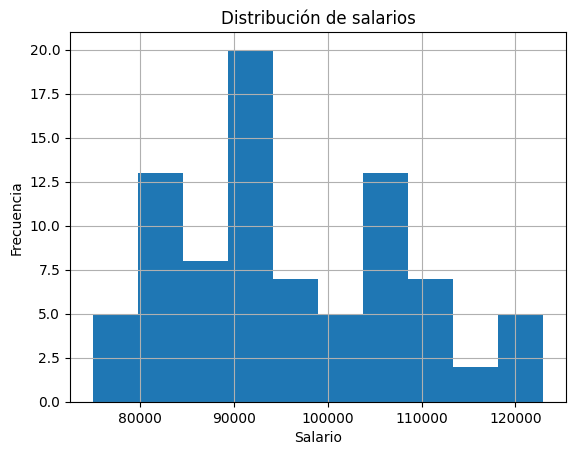

In [8]:
# Histograma de salary
import matplotlib.pyplot as plt

df['salary'].hist()
plt.title("Distribución de salarios")
plt.xlabel("Salario")
plt.ylabel("Frecuencia")
plt.show()

**Observaciones:**
- Distribución aproximadamente normal
- Ligera concentración de valores entre 85k-105k

Text(0, 0.5, 'Salario')

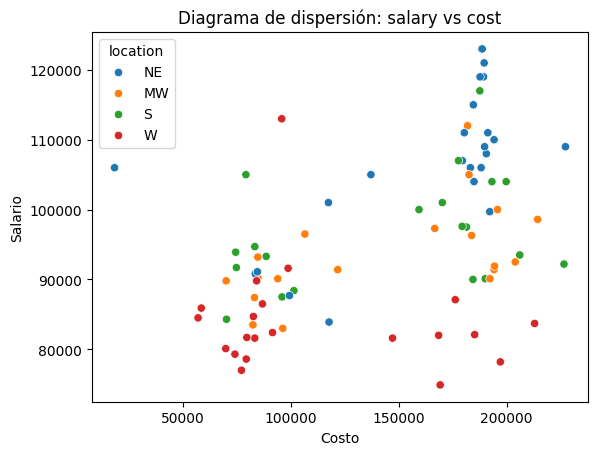

In [9]:
# Diagrama de dispersión de salary vs cost por location
import seaborn as sns

df['location'] = 'MW'
df.loc[df['location_NE'] == 1, 'location'] = 'NE'
df.loc[df['location_S'] == 1, 'location'] = 'S'
df.loc[df['location_W'] == 1, 'location'] = 'W'

sns.scatterplot(data=df, x='cost', y='salary', hue='location')
plt.title("Diagrama de dispersión: salary vs cost")
plt.xlabel("Costo")
plt.ylabel("Salario")

**Observaciones:**
- Existe relación positiva entre costo y salario
- Algunas regiones como NE tienden a salarios más altos
- En promedio, W parece tener salarios más bajos

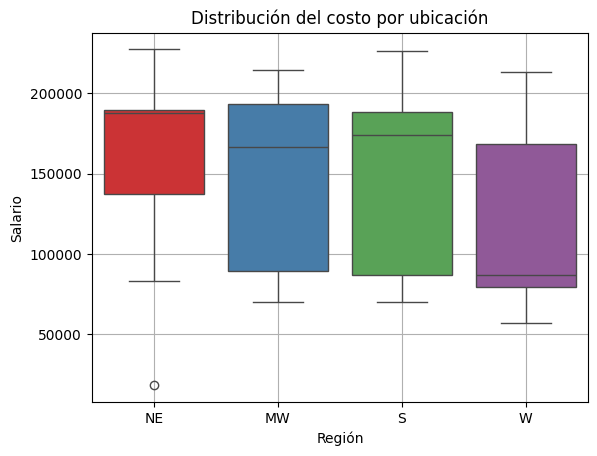

In [10]:
# Boxplot de cost por location
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x='location', y='cost', hue='location', palette='Set1')
plt.title("Distribución del costo por ubicación")
plt.xlabel('Región')
plt.ylabel('Salario')
plt.grid(True)
plt.show()

**Observaciones:**

- El boxplot muestra que existen diferencias en los costos entre las distintas ubicaciones.
- Algunas regiones presentan medianas más altas y mayor dispersión, lo que indica variabilidad en los costos.
- Se observan valores atípicos en ciertas localidades.
- La ubicación parece influir en el costo.

# 3. Construcción del modelo de regresión

- Construye el modelo de regresión usando los datos de salario, costo y location. Recuerda que esta última debe ser en su versión codificada con one-hot encoding.
- Imprime los coeficientes e interpreta qué significan cuando se sustituyen valores en costo, y location (versión codificada). Si no recuerdas cómo se hace esta interpretación consulta los videos.


In [11]:
# Modelo de regresión usando salary, cost y location (one-hot encoding con Pandas)
df_dummies = pd.get_dummies(df['location'], drop_first=True)

df_model = pd.concat([df[['salary','cost']], df_dummies], axis=1)
df_model = df_model.astype(int)

In [12]:
# Cálculo de coeficientes
from sklearn.linear_model import LinearRegression

X = df_model.drop('salary', axis=1)
y = df_model['salary']

model = LinearRegression().fit(X, y)

print("Coeficientes:")
print(f"Intercepto: {model.intercept_:.2f}")
print(f"cost: {model.coef_[0]:.2f}")
print(f"location_NE: {model.coef_[1]:.2f}")
print(f"location_S: {model.coef_[2]:.2f}")
print(f"location_W: {model.coef_[3]:.2f}")

Coeficientes:
Intercepto: 84988.72
cost: 0.06
location_NE: 12032.82
location_S: 2800.35
location_W: -7721.42


**Interpretación:**
- Por cada aumento de 1 unidad en costo, el salario aumenta ~0.0605
- Estar en NE aumenta salario ~12k respecto a la categoría base (MW)
- Estar en W reduce salario ~7.7k
- MW es la categoría de referencia (porque se eliminó)

# 4. Análisis de Residuos

- Construyen una visualización de predicciones (salario estimado) vs valores reales (salario real).
- Crea una gráfica de los errores residuales. Discute lo que observas

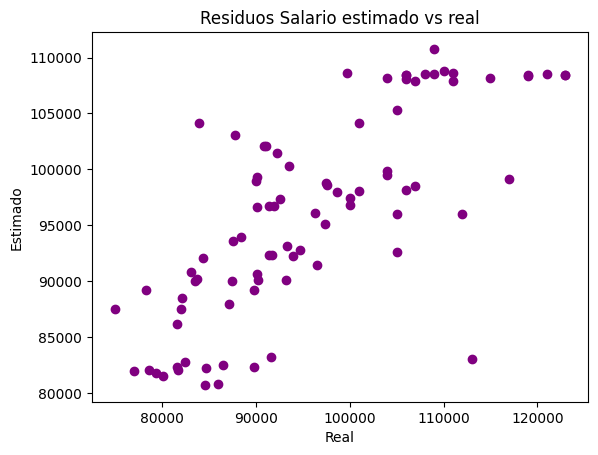

In [13]:
# Visualización de predicciones: salario estimado vs salario real
y_pred = model.predict(X)

plt.scatter(y, y_pred, color='purple')
plt.title("Residuos Salario estimado vs real")
plt.xlabel("Real")
plt.ylabel("Estimado")
plt.show()

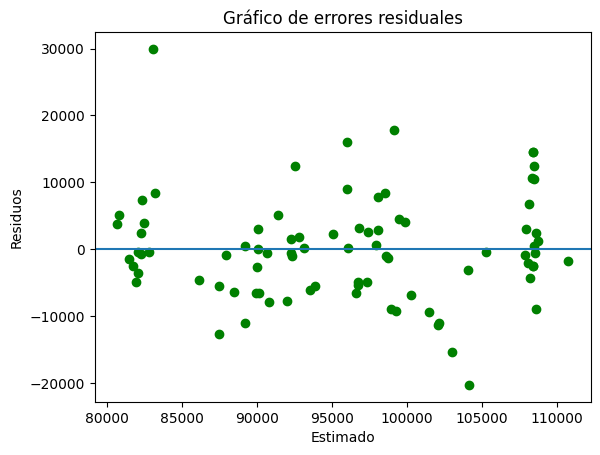

In [14]:
# Gráfica de errores residuales
residuos = y - y_pred

plt.scatter(y_pred, residuos, color='green')
plt.title("Gráfico de errores residuales")
plt.xlabel("Estimado")
plt.ylabel("Residuos")
plt.axhline(0)
plt.show()

**Observaciones:**
- Los puntos siguen una tendencia lineal, por lo que se considera un buen ajuste
- La mayoría de los residuos dispersos se encuentran alrededor de 0, por lo que se considera un modelo razonable
- Aunque no se observa un patrón fuerte, los supuestos se consideran aceptables

# 5. Evalúa el modelo

- Calcula el MSE del modelo construido. Recuerda que usas el propio conjunto de datos (No hablamos nada de entrenamiento y test).
- Calcula el R² Score

Discute estos resultados obtenidos.

In [15]:
from sklearn.metrics import mean_squared_error, r2_score

# Cálculo del MSE
mse = mean_squared_error(y, y_pred)
# Cálculo del R2 Score
r2 = r2_score(y, y_pred)

print("\nEvaluación del modelo:")
print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"R² (R-squared): {r2:.4f}")


Evaluación del modelo:
Error cuadrático medio (MSE): 60480269.15
R² (R-squared): 0.5705


**Observaciones:**
- El modelo explica 57% de la variabilidad
- Se tiene un ajuste moderado (no excelente, pero útil)
- Puede haber variables faltantes que podrían mejorar el modelo

# 6. Realiza un análisis de varianza con stastmodel

Consulta esto aquí https://www.statsmodels.org/dev/examples/notebooks/generated/variance_components.html

In [16]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Crear dataframe original con categórica
model_sm = smf.ols('salary ~ cost + C(location)', data=df).fit()

anova_table = sm.stats.anova_lm(model_sm, typ=2)
print(anova_table)

                   sum_sq    df          F        PR(>F)
C(location)  4.071774e+09   3.0  21.121259  3.570975e-10
cost         7.878166e+08   1.0  12.259774  7.600629e-04
Residual     5.140823e+09  80.0        NaN           NaN


**Observaciones:**
- Los resultados del ANOVA indican que tanto la variable categórica location como la variable numérica cost son estadísticamente significativas (p < 0.05).
- Esto implica que ambas variables influyen en el salario.
- Además, location presenta un mayor valor de F, lo que sugiere que tiene un impacto más fuerte en comparación con cost.